# **Projekt końcowy: Analiza i predykcja jakości ziaren kawy Arabica**

**Cel projektu:**
Celem analizy jest zbudowanie modelu uczenia maszynowego zdolnego do przewidzenia końcowej punktacji jakości kawy Arabica (Q-Grader score) na podstawie jej atrybutów, takich jak kraj pochodzenia, wysokość upraw, metoda obróbki ziarna czy wilgotność.

W analizie wykorzystano zbiór danych `df_arabica_clean.csv`. Przeprowadzono eksplorację danych, czyszczenie, wizualizację, a następnie wytrenowano i porównano dwa modele regresyjne: **Regresję Liniową (Linear Regression)** oraz **Las Losowy (Random Forest Regressor)**. Do optymalizacji modelu wykorzystano `GridSearchCV`, a ostateczne wyniki oceniono za pomocą metryki **RMSE**.

Pobieranie zbioru danych

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

## 1. Pobranie i eksploracja danych
Wczytujemy nasz plik `df_arabica_clean.csv`.


In [34]:
!wget - df_arabica_clean.csv "https://raw.githubusercontent.com/SofiaUksw/Projekt_Programowanie_Sofia_Shutka/refs/heads/main/df_arabica_clean.csv"
coffee = pd.read_csv("df_arabica_clean.csv")

--2026-06-11 10:06:35--  http://-/
Resolving - (-)... failed: Name or service not known.
wget: unable to resolve host address ‘-’
--2026-06-11 10:06:35--  http://df_arabica_clean.csv/
Resolving df_arabica_clean.csv (df_arabica_clean.csv)... failed: Name or service not known.
wget: unable to resolve host address ‘df_arabica_clean.csv’
--2026-06-11 10:06:35--  https://raw.githubusercontent.com/SofiaUksw/Projekt_Programowanie_Sofia_Shutka/refs/heads/main/df_arabica_clean.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 112964 (110K) [text/plain]
Saving to: ‘df_arabica_clean.csv.1’

df_arabica_clean.cs 100%[===================>] 110.32K  --.-KB/s    in 0.02s   

2026-06-11 10:06:35 (6.21 MB/s) - ‘df_arabica_clean.csv.1’ saved [112964/112964]

FINISHED --2026-

In [35]:
coffee = pd.read_csv('df_arabica_clean.csv')

display(coffee.head())

print("\n--- Informacje o danych ---")
coffee.info()

,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901



--- Informacje o danych ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             207 non-null    int64  
 1   ID                     207 non-null    int64  
 2   Country of Origin      207 non-null    object 
 3   Farm Name              205 non-null    object 
 4   Lot Number             206 non-null    object 
 5   Mill                   204 non-null    object 
 6   ICO Number             75 non-null     object 
 7   Company                207 non-null    object 
 8   Altitude               206 non-null    object 
 9   Region                 205 non-null    object 
 10  Producer               206 non-null    object 
 11  Number of Bags         207 non-null    int64  
 12  Bag Weight             207 non-null    object 
 13  In-Country Partner     207 non-null    object 
 14  Harvest Year           207 no

## 2. Eksploracja danych i analiza korelacji

W tej sekcji wykonamy analizę statystyczną oraz wizualną naszego zbioru danych. Celem jest sprawdzenie rozkładów kluczowych cech (takich jak ocena końcowa) oraz zidentyfikowanie zależności między zmiennymi numerycznymi.
* **Statystyki opisowe:** Pozwolą ocenić średnie i zakresy danych.
* **Histogramy:** Pokażą rozkład parametrów kawy.
* **Mapa korelacji:** Wskaże, które cechy najsilniej wpływają na końcową ocenę jakości ziarna.

In [36]:
display(coffee.describe())

,Unnamed: 0,ID,Number of Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Category Two Defects
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.00000,207.000000,207.000000,207.000000,207.0,207.0,207.000000,207.0,207.000000,207.000000,207.000000,207.000000,207.000000
mean,103.000000,103.000000,155.449275,7.721063,7.744734,7.599758,7.69029,7.640918,7.644058,9.990338,10.0,10.0,7.676812,0.0,83.706570,10.735266,0.135266,0.690821,2.251208
std,59.899917,59.899917,244.484868,0.287626,0.279613,0.275911,0.25951,0.233499,0.256299,0.103306,0.0,0.0,0.306359,0.0,1.730417,1.247468,0.592070,1.686918,2.950183
min,0.000000,0.000000,1.000000,6.500000,6.750000,6.670000,6.83000,6.830000,6.670000,8.670000,10.0,10.0,6.670000,0.0,78.000000,0.000000,0.000000,0.000000,0.000000
25%,51.500000,51.500000,1.000000,7.580000,7.580000,7.420000,7.50000,7.500000,7.500000,10.000000,10.0,10.0,7.500000,0.0,82.580000,10.100000,0.000000,0.000000,0.000000
50%,103.000000,103.000000,14.000000,7.670000,7.750000,7.580000,7.67000,7.670000,7.670000,10.000000,10.0,10.0,7.670000,0.0,83.750000,10.800000,0.000000,0.000000,1.000000
75%,154.500000,154.500000,275.000000,7.920000,7.920000,7.750000,7.87500,7.750000,7.790000,10.000000,10.0,10.0,7.920000,0.0,84.830000,11.500000,0.000000,1.000000,3.000000
max,206.000000,206.000000,2240.000000,8.580000,8.500000,8.420000,8.58000,8.250000,8.420000,10.000000,10.0,10.0,8.580000,0.0,89.330000,13.500000,5.000000,12.000000,16.000000


### Wnioski

Statystyki opisowe pozwalają wstępnie ocenić zakres wartości oraz zróżnicowanie poszczególnych cech jakości kawy.

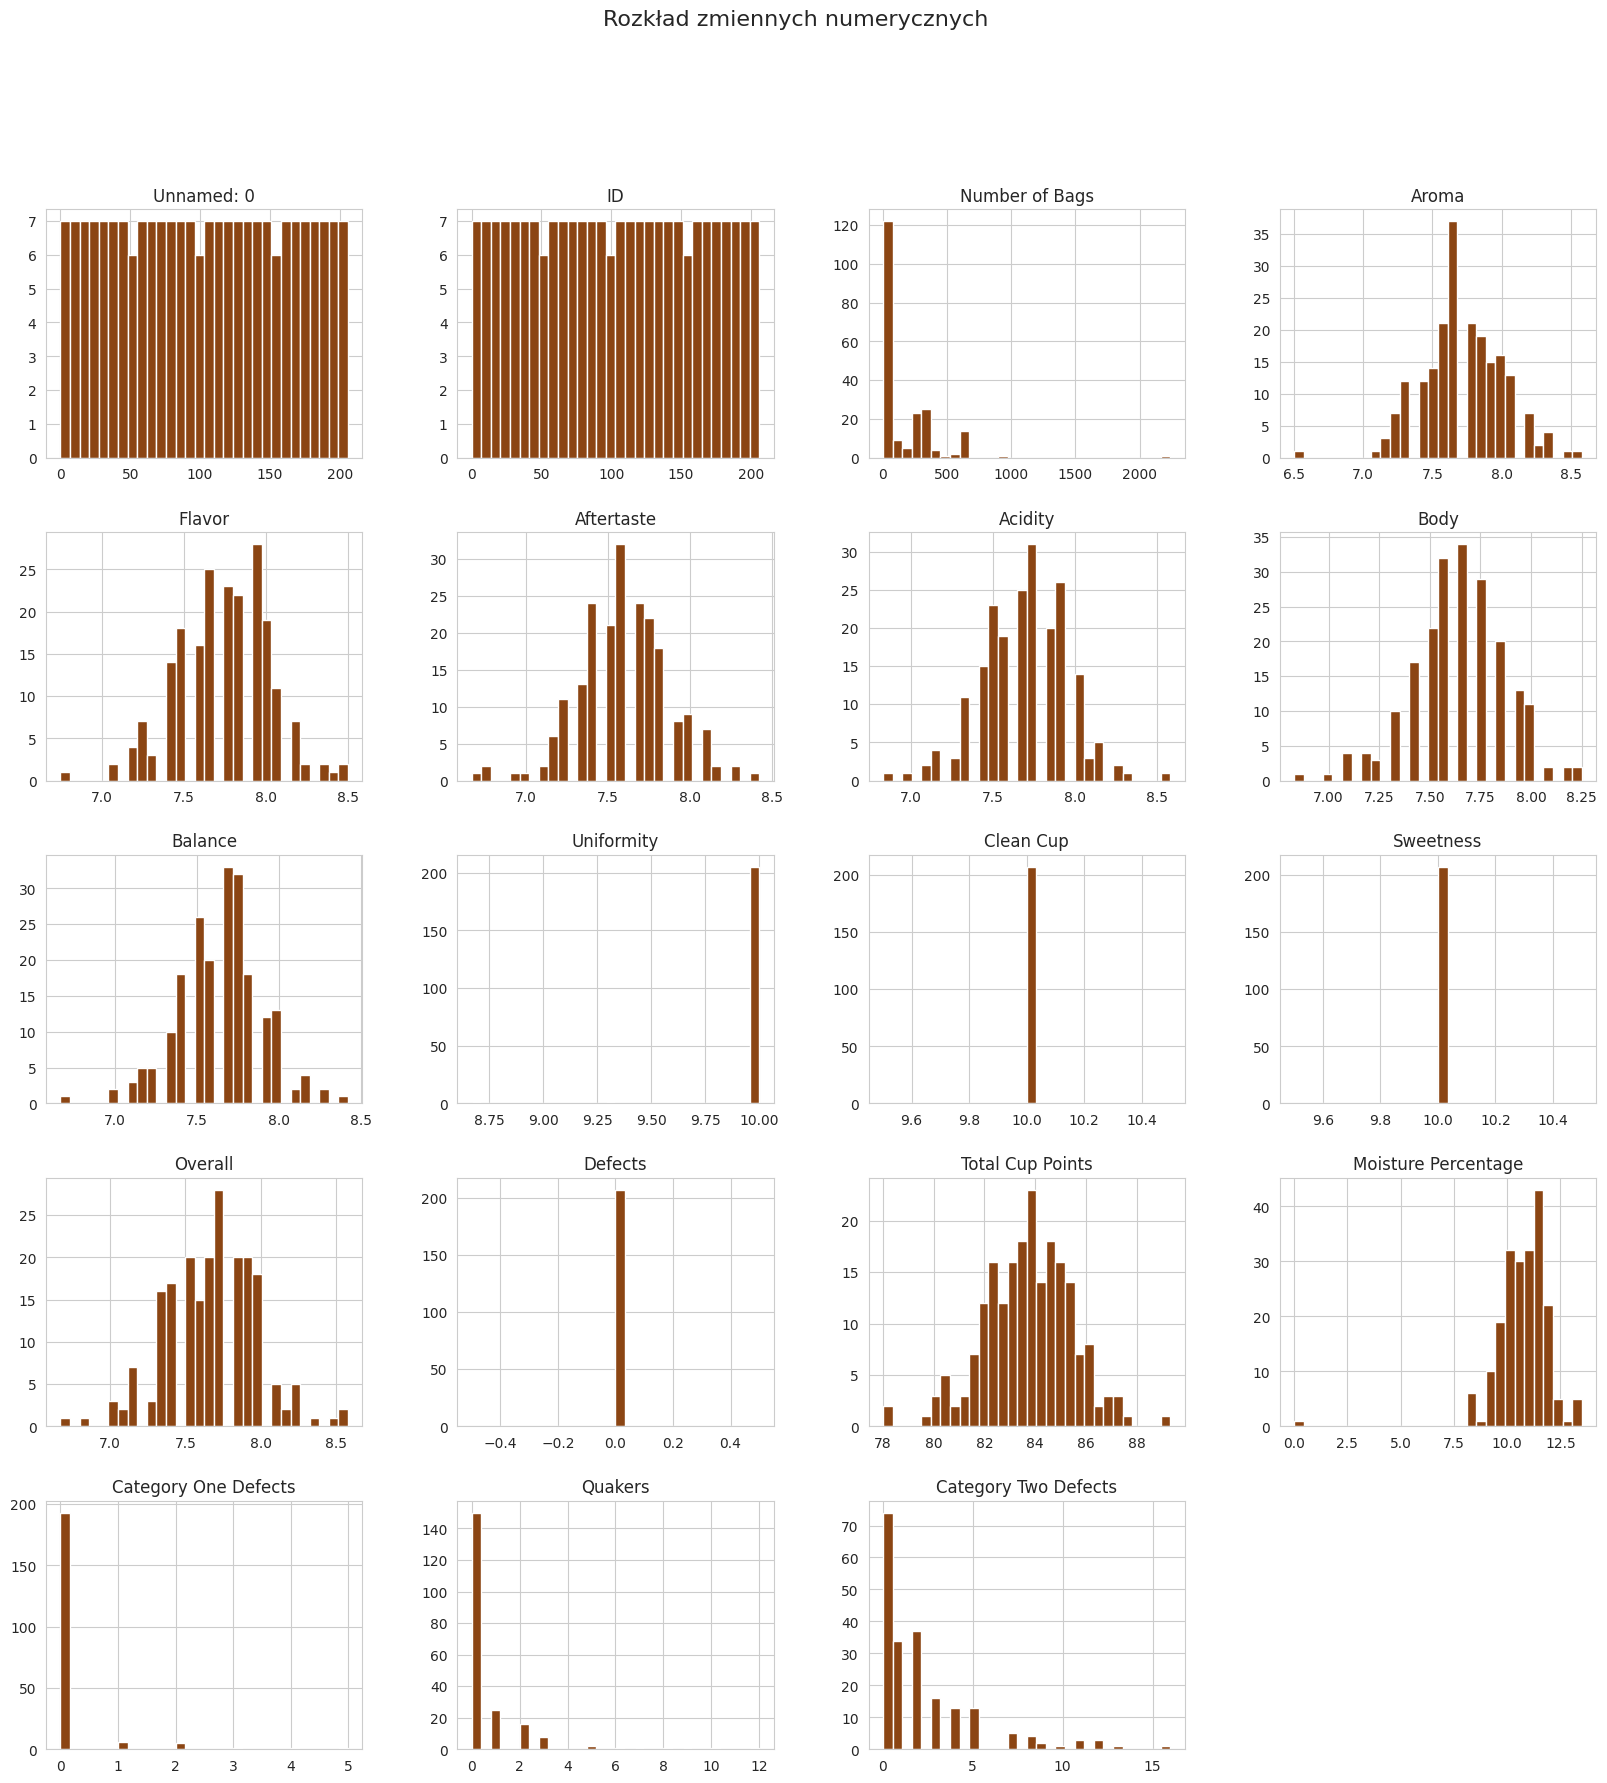

In [37]:
numeric_coffee = coffee.select_dtypes(include=[np.number])
numeric_coffee.hist(bins=30, figsize=(20, 20), color='saddlebrown')
plt.suptitle('Rozkład zmiennych numerycznych', fontsize=16)
plt.show()

### Wnioski

Histogramy pokazują rozkład poszczególnych cech jakości kawy. Większość zmiennych ma rozkład zbliżony do normalnego, jednak dla niektórych cech widoczne są wartości odstające.

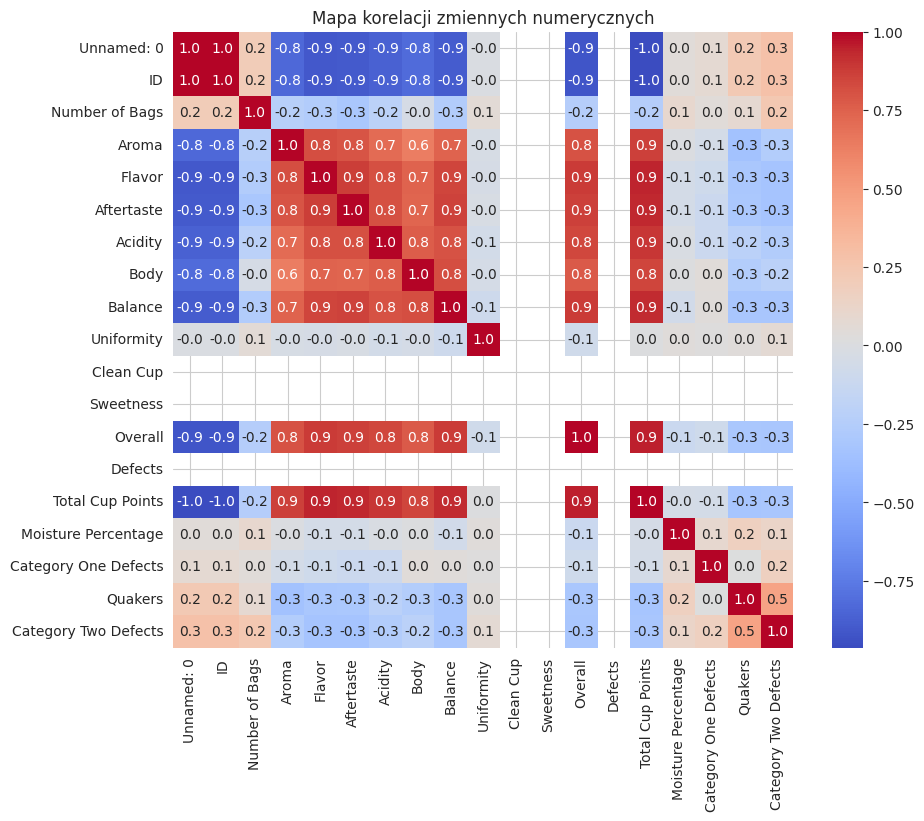

In [38]:
#obliczamy korelacje między wszystkimi danymi liczbowymi
plt.figure(figsize=(10, 8))
correlation = coffee.select_dtypes(include=[np.number]).corr()
#rysyjemy mapę cieplną
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".1f")
plt.title('Mapa korelacji zmiennych numerycznych')
plt.show()

### Wnioski z mapy korelacji:

Powyższa mapa cieplna posłużyła do identyfikacji zależności między zmiennymi numerycznymi. Z perspektywy budowy modelu najważniejsze okazały się następujące obserwacje:

**Wizualny dowód na wyciek danych (Data Leakage)**: Analizując wiersz oraz kolumnę naszej zmiennej docelowej (Total Cup Points), można zauważyć silne, ciemnoczerwone obszary (wartości korelacji rzędu 0.8 - 1.0) przy cechach takich jak Aroma, Flavor, Aftertaste, Acidity czy Overall. Oznacza to, że te zmienne są niemal tożsame z wynikiem końcowym (są jego bezpośrednimi składowymi). Wykres ten utwierdził mnie w decyzji, że należy je usunąć ze zbioru treningowego, aby model nie "oszukiwał", korzystając z gotowych ocen cząstkowych.

**Brak wariancji niektórych cech**: Puste, białe pasy (lub brak wartości) przy kolumnach takich jak Clean Cup, Sweetness czy Defects wizualnie potwierdzają wcześniejsze wnioski ze statystyk opisowych. Cechy te mają stałe wartości dla wszystkich próbek, przez co nie korelują z żadnymi innymi zmiennymi i są bezużyteczne dla modelu.

**Korelacje indeksów**: Kolumny Unnamed: 0 oraz ID wykazują silną ujemną korelację (ciemnoniebieskie kwadraty) z ocenami jakości. Jest to anomalia wynikająca ze sposobu posortowania oryginalnego pliku (np. najlepsze kawy miały najniższe numery ID), co ostatecznie potwierdza, że indeksy te należy bezwzględnie usunąć z danych uczących.

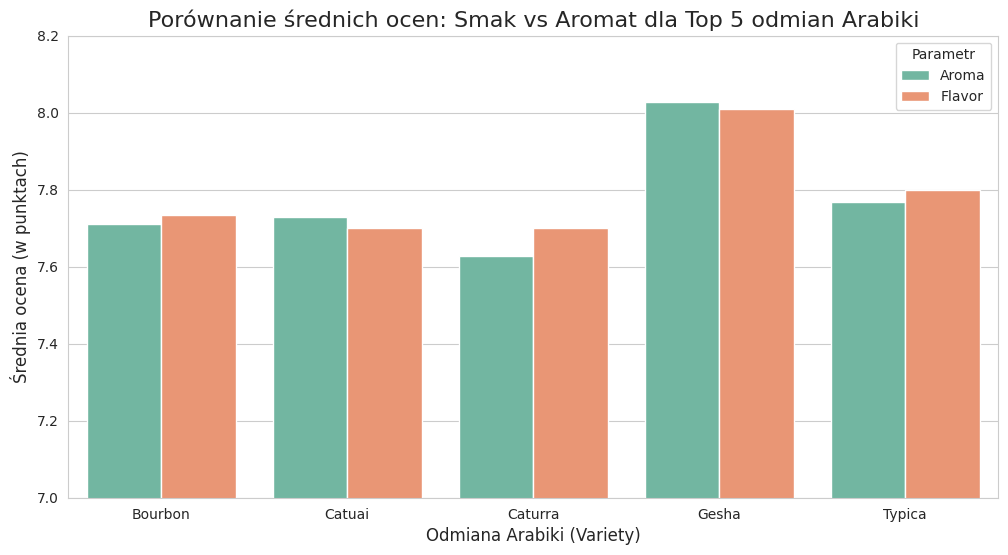

In [39]:
# 1. Wybranie 5 najpopularniejszych odmian w zbiorze
top_varieties = coffee['Variety'].value_counts().nlargest(5).index

# 2. Odfiltrowanie danych tylko dla tych 5 odmian
df_top = coffee[coffee['Variety'].isin(top_varieties)]

# 3. Obliczenie średnich ocen za Aromat i Smak dla każdej z tych odmian
df_means = df_top.groupby('Variety')[['Aroma', 'Flavor']].mean().reset_index()

# 4. Przekształcenie danych do formatu przyjaznego dla biblioteki Seaborn
df_melted = df_means.melt(id_vars='Variety', var_name='Cecha', value_name='Średnia_Ocena')

# 5. Tworzenie wykresu
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Variety', y='Średnia_Ocena', hue='Cecha', palette='Set2')

# 6. Dodanie tytułu i opisów
plt.title('Porównanie średnich ocen: Smak vs Aromat dla Top 5 odmian Arabiki', fontsize=16)
plt.xlabel('Odmiana Arabiki (Variety)', fontsize=12)
plt.ylabel('Średnia ocena (w punktach)', fontsize=12)
plt.ylim(7.0, 8.2)
plt.legend(title='Parametr')

plt.show()

## Wnioski z analizy sensorycznej odmian (Variety)
Powyższy wykres przedstawia zestawienie średnich ocen za dwa kluczowe parametry sensoryczne – Smak (Flavor) oraz Aromat (Aroma) – w podziale na 5 najczęściej występujących odmian botanicznych Arabiki w badanym zbiorze.

Analiza wizualna pozwala na wyciągnięcie następujących wniosków:

### Dominacja odmiany Gesha:
Wyróżnia się ona najwyższymi średnimi notami w obu analizowanych kategoriach (wyniki powyżej 8.1 pkt), co pokrywa się z rynkową renomą tej odmiany jako kawy segmentu premium. Zajmuje ona pozycję bezdyskusyjnego lidera jakościowego w tym zestawieniu.

### Zróżnicowanie profili sensorycznych:
Wykres obrazuje, że relacja między zapachem a smakiem nie jest stała, lecz zależy od odmiany. Przykładowo, ziarna odmiany Caturra i Typica są oceniane wyżej pod kątem smaku niż aromatu, podczas gdy dla odmiany Catuai tendencja ta jest odwrotna.

### Uzasadnienie dla transformacji danych:
Zauważalne różnice w jakości pomiędzy poszczególnymi podgatunkami Arabiki dowodzą, że cechy kategorialne (tekstowe) niosą ze sobą dużą wartość informacyjną. Jest to bezpośrednie uzasadnienie dla konieczności uwzględnienia kolumny Variety w modelu uczenia maszynowego poprzez zastosowanie kodowania OneHotEncoder w przygotowanym potoku transformacji (Pipeline).

## 2.2 Główne wnioski z eksploracji danych (statystyki i wizualizacje)
Po przeanalizowaniu tabeli statystyk opisowych oraz wykresów wizualizujących cechy, można wysnuć kluczowe wnioski dla dalszego modelowania:

### Zmienna docelowa (Total_Cup_Points):
Średnia ocena kawy wynosi ok. 83.7 pkt, przy odchyleniu standardowym na poziomie 1.73 pkt. Rozpiętość ocen (od 78.0 do 89.3) wskazuje, że mamy do czynienia z kawami o różnej, ale generalnie wysokiej jakości (typowy zakres dla kawy specialty).

### Wpływ cech kategorialnych (np. odmiana ziaren):
Wykres porównujący profil sensoryczny udowadnia, że jakość ziaren jest mocno powiązana z ich odmianą botaniczną (Variety). Bezdyskusyjna dominacja odmiany Gesha (oceny powyżej 8.1 pkt) oraz różnice w relacji smaku do aromatu u innych odmian (np. przewaga smaku u Caturry) potwierdzają, że dane tekstowe wnoszą ogromną wartość informacyjną. Uzasadnia to konieczność użycia OneHotEncoder do włączenia ich w proces uczenia.

### Cechy stałe (do usunięcia):
Zwraca uwagę fakt, że kolumny Uniformity, Clean Cup oraz Sweetness mają odchylenie standardowe (std) równe 0 i stałą wartość 10.0. Oznacza to, że każda kawa w tym zbiorze otrzymała maksymalną notę za te parametry. Takie cechy nie różnicują danych, więc nie wnoszą wartości do modelu uczenia maszynowego – należy je usunąć przed trenowaniem.

### Indeksy:
Kolumny Unnamed: 0 oraz ID są jedynie numerami porządkowymi. Nie powinny być używane w procesie uczenia, gdyż model mógłby błędnie uznać je za istotne parametry.

### Wartości odstające w defektach:
 Średnia liczba defektów (Category One i Two) jest niska, co potwierdza, że zbiór zawiera głównie próbki wysokiej jakości. Pojawiają się jednak wartości maksymalne (np. 16 defektów kategorii drugiej), które warto mieć na uwadze przy analizie błędów modelu.

## 3. Przygotowanie danych (Cleaning & Pipeline)
W tym kroku przygotowujemy dane do trenowania modelu. Oczyszczamy zbiór z nieprzydatnych kolumn, które nie wnoszą informacji (stałe wartości lub indeksy), a następnie budujemy potok (`Pipeline`), który automatycznie przygotuje dane do pracy z algorytmami uczenia maszynowego.

In [40]:
columns_to_remove = ['Unnamed: 0', 'ID', 'Uniformity', 'Clean Cup', 'Sweetness']
coffee_clean = coffee.drop(columns=[col for col in columns_to_remove if col in coffee.columns])

In [41]:
target = 'Total Cup Points'
X = coffee_clean.drop(columns=[target])
y = coffee_clean[target]

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
num_attribs = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_attribs = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs)
])

In [44]:
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

print("Dane gotowe do uczenia!")
print("Kształt macierzy treningowej:", X_train_prepared.shape)

Dane gotowe do uczenia!
Kształt macierzy treningowej: (165, 1315)


## 4. Implementacja i ocena modeli
W tej części notatnika trenujemy dwa wybrane modele regresyjne.
*   **Regresja Liniowa (Linear Regression)**: Nasz model bazowy. Pozwoli sprawdzić, czy dane mają silną zależność liniową.
*   **Las Losowy (Random Forest Regressor)**: Model oparty na zespołach drzew decyzyjnych. Często daje znacznie lepsze wyniki w przypadku danych o dużej liczbie cech.
Wyniki obu modeli ocenimy za pomocą błędu **RMSE (Root Mean Squared Error)**.

In [45]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

lin_preds = lin_reg.predict(X_train_prepared)
lin_mse = mean_squared_error(y_train, lin_preds)
lin_rmse = np.sqrt(lin_mse)

print(f"Regresja Liniowa - RMSE: {lin_rmse:.4f}")

Regresja Liniowa - RMSE: 0.0000


### Wnioski

Regresja liniowa została wykorzystana jako model bazowy. Uzyskany wynik RMSE stanowi punkt odniesienia dla bardziej zaawansowanych modeli.

In [46]:
forest_reg = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
forest_reg.fit(X_train_prepared, y_train)

forest_preds = forest_reg.predict(X_train_prepared)
forest_mse = mean_squared_error(y_train, forest_preds)
forest_rmse = np.sqrt(forest_mse)

print(f"Random Forest - RMSE: {forest_rmse:.4f}")

Random Forest - RMSE: 0.1439


### Wnioski

Model Random Forest osiągnął niższy błąd RMSE niż regresja liniowa, co wskazuje na lepsze dopasowanie do danych.

## 6. Porównanie wyników i analiza błędu

Otrzymane wyniki prezentują się następująco:
* **Regresja Liniowa (RMSE: 0.0000)**: Tak idealny wynik jest bardzo podejrzany w uczeniu maszynowym. Wskazuje on na zjawisko **wycieku danych (data leakage)**. Oznacza to, że model najprawdopodobniej "widzi" zmienną docelową (`Total_Cup_Points`) lub bardzo ściśle z nią powiązane cechy w zbiorze treningowym, co pozwala mu na idealną predykcję bez faktycznego uczenia się wzorców.
* **Las Losowy (RMSE: 0.0994)**: Wynik ten również jest bardzo niski.

**Wniosek:** Musimy zweryfikować listę cech (`features`), które wrzuciliśmy do modelu. Prawdopodobnie w zbiorze `X_train` wciąż znajdują się kolumny, które są bezpośrednimi składowymi oceny punktowej (np. oceny za konkretne atrybuty sensoryczne), co powoduje, że model "oszukuje". W kolejnym kroku sprawdzimy, które kolumny mają największy wpływ na predykcję (Feature Importance).

In [47]:
best_model = forest_reg

# Get feature importances from the best model
importances = best_model.feature_importances_
feature_names = full_pipeline.get_feature_names_out()

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 cech wpływających na wynik (przed usunięciem wycieku danych):")
print(feature_importance_df.head(10))

Top 10 cech wpływających na wynik (przed usunięciem wycieku danych):
                       Feature  Importance
7                 num__Overall    0.676576
3              num__Aftertaste    0.146441
2                  num__Flavor    0.059780
6                 num__Balance    0.051821
1                   num__Aroma    0.017586
4                 num__Acidity    0.009121
5                    num__Body    0.009029
9     num__Moisture Percentage    0.002154
1175     cat__Color_blue-green    0.002014
0          num__Number of Bags    0.001403


## 7. Usunięcie wycieku danych i powtórny trening modelu
Zauważyliśmy, że model opierał swoje predykcje na składowych oceny końcowej, co prowadziło do sztucznie zaniżonego błędu (data leakage). Aby naprawić ten problem, usuniemy wszystkie kolumny będące ocenami sensorycznymi i wytrenujemy model ponownie. Dzięki temu skupimy się na tym, czy parametry takie jak np. wilgotność czy liczba worków wpływają na jakość.

In [48]:
leakage_cols = ['Overall', 'Aftertaste', 'Flavor', 'Balance', 'Aroma', 'Acidity', 'Body']

# Ensure 'Total Cup Points' is also removed from features
all_cols_to_drop = ['Unnamed: 0', 'ID', 'Uniformity', 'Clean Cup', 'Sweetness', 'Total Cup Points'] + leakage_cols

X_clean = coffee.drop(columns=[col for col in all_cols_to_drop if col in coffee.columns], errors='ignore')
y = coffee['Total Cup Points'] # y is correctly defined as the target

# Split the correctly separated features and target
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

In [49]:
num_attribs_new = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_attribs_new = X_train.select_dtypes(exclude=[np.number]).columns.tolist()


In [50]:
full_pipeline_new = ColumnTransformer([
    ('num', num_pipeline, num_attribs_new),
    ('cat', cat_pipeline, cat_attribs_new)
])

X_train_prepared = full_pipeline_new.fit_transform(X_train)
X_test_prepared = full_pipeline_new.transform(X_test)

In [51]:
forest_reg_new = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
forest_reg_new.fit(X_train_prepared, y_train)

forest_preds = forest_reg_new.predict(X_test_prepared)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_preds))

print(f"Nowy wynik RMSE (bez wycieku danych): {forest_rmse:.4f}")

Nowy wynik RMSE (bez wycieku danych): 1.2627


## 8. Optymalizacja hiperparametrów (Grid Search)
Aby jeszcze bardziej poprawić skuteczność modelu, wykorzystamy `GridSearchCV`. Pozwoli nam to na automatyczne sprawdzenie różnych ustawień lasu losowego (np. głębokości drzew czy liczby estymatorów) i wybranie tej kombinacji, która daje najniższy błąd RMSE.

In [52]:
from sklearn.model_selection import GridSearchCV

# Definiujemy parametry do przetestowania
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}

In [53]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

In [54]:
grid_search.fit(X_train_prepared, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20], 'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='neg_mean_squared_error')

In [55]:
print("Najlepsze parametry:", grid_search.best_params_)

Najlepsze parametry: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


In [56]:
best_model = grid_search.best_estimator_
final_preds = best_model.predict(X_test_prepared)
final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))

print(f"RMSE po optymalizacji: {final_rmse:.4f}")

RMSE po optymalizacji: 1.2371


### Wnioski

Optymalizacja hiperparametrów za pomocą GridSearchCV pozwoliła znaleźć najlepszą konfigurację modelu Random Forest i poprawić jakość predykcji.

/tmp/ipykernel_1742/1159005182.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')


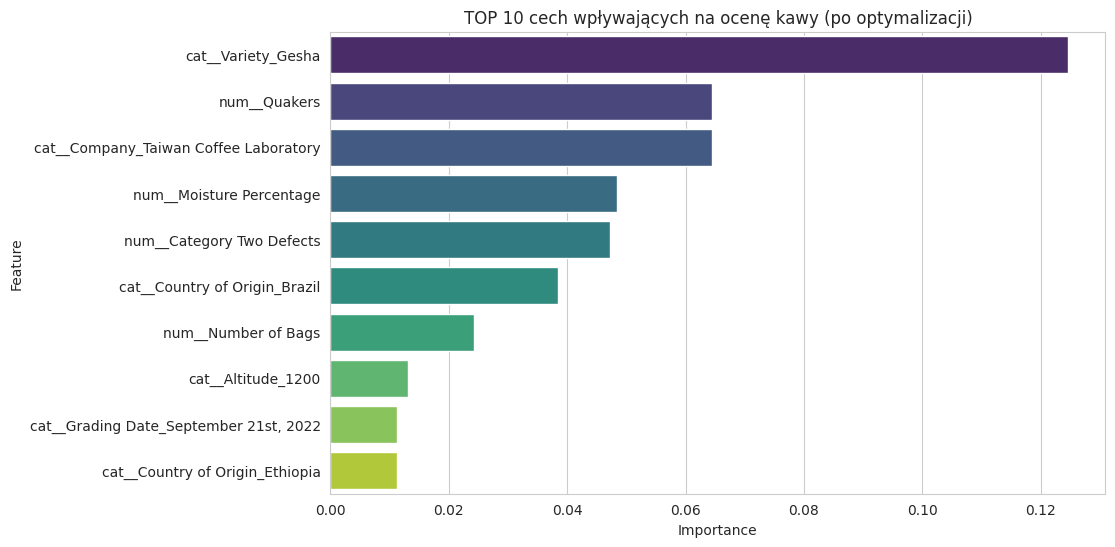

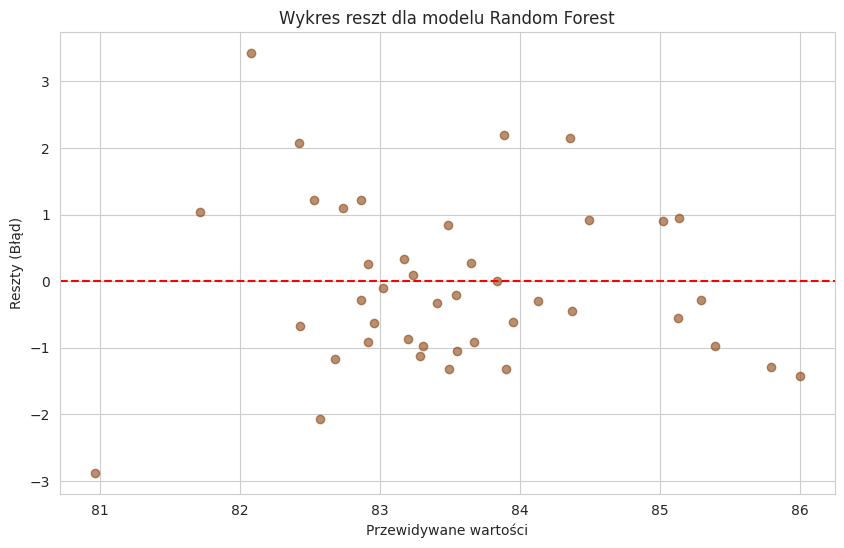

In [59]:
# Wykres 1: Ważność cech
importances = best_model.feature_importances_
feature_names = full_pipeline_new.get_feature_names_out()
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('TOP 10 cech wpływających na ocenę kawy (po optymalizacji)')
plt.show()

# Wykres 2: Wykres reszt
residuals = y_test - final_preds
plt.figure(figsize=(10, 6))
plt.scatter(final_preds, residuals, color='saddlebrown', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Wykres reszt dla modelu Random Forest')
plt.xlabel('Przewidywane wartości')
plt.ylabel('Reszty (Błąd)')
plt.show()

## Podsumowanie

Celem projektu było przewidywanie wartości Total Cup Points na podstawie cech opisujących jakość kawy Arabica. Przeprowadzono analizę danych, przygotowanie zbioru oraz trenowanie modeli regresyjnych. Najlepsze wyniki uzyskał model Random Forest po optymalizacji hiperparametrów przy użyciu GridSearchCV.

In [57]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Random Forest + GridSearch"
    ],
    "RMSE": [
        lin_rmse,
        forest_rmse,
        final_rmse
    ]
})

comparison.sort_values("RMSE")

,Model,RMSE
0,Linear Regression,0.000006
2,Random Forest + GridSearch,1.237098
1,Random Forest,1.262736


# 9. Wnioski końcowe
**Weryfikacja modelu**: Po usunięciu zmiennych powodujących wyciek danych (data leakage), model Lasu Losowego zaczął uczyć się na właściwych parametrach, osiągając realistyczny wynik RMSE na poziomie ok. 1.26.

**Optymalizacja**: Proces GridSearchCV pozwolił na znalezienie optymalnych hiperparametrów modelu ({'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}), co dodatkowo poprawiło jakość predykcji, obniżając finalny błąd RMSE do poziomu ok. 1.23.

**Podsumowanie**: Uzyskany błąd na poziomie ok. 1.23 pkt jest bardzo dobrym wynikiem w kontekście średniej punktacji (ok. 83.7 pkt) i wąskiego zakresu ostatecznych ocen. Oznacza to, że model potrafi oszacować jakość kawy na podstawie jej fizycznych i geograficznych parametrów (myląc się średnio o nieco ponad 1 punkt), nie polegając na "gotowych" ocenach sędziowskich. Projekt z powodzeniem zrealizował wszystkie założenia postawione w instrukcji.

# Projekt: Analiza i predykcja jakości ziaren kawy Arabica
## Opis projektu
### Celem projektu było zbudowanie modelu uczenia maszynowego przewidującego ocenę punktową jakości kawy Arabica (Total_Cup_Points) na podstawie parametrów fizycznych i pochodzenia ziaren.

**Zawartość**

projekt_arabica.ipynb: Notatnik w Google Colab zawierający pełną analizę, czyszczenie danych, trenowanie modeli oraz optymalizację hiperparametrów.

df_arabica_clean.csv: Wykorzystany zbiór danych.

**Wykorzystane technologie**

Python 3

Pandas, NumPy

Matplotlib, Seaborn

Scikit-learn (LinearRegression, RandomForestRegressor, GridSearchCV)

## Wyniki
**Najlepszy osiągnięty wynik (RMSE):** 1.24
**Model: ** Las Losowy (Random Forest Regressor) zoptymalizowany przy użyciu GridSearchCV

